# Static dense embeddings: GloVe and FastText

Static embeddings assign one learned, fixed-length vector to each vocabulary item. This notebook makes that idea concrete with pretrained GloVe vectors, then contrasts its fixed vocabulary with FastText character n-grams. You will inspect nearest neighbours, test an approximate vector relationship, reduce a few vectors for visualization, and construct a vector for an unseen spelling.

The notebook runs on CPU. Its first execution downloads the bounded `glove-wiki-gigaword-50` vectors and can take several minutes. Later executions reuse the local Gensim cache.


In [1]:
import gensim.downloader as api
from gensim.models import FastText
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 50-dimensional GloVe vectors trained on Wikipedia 2014 + Gigaword 5.
vectors = api.load('glove-wiki-gigaword-50')
print(f'vocabulary size: {len(vectors):,}; vector width: {vectors.vector_size}')


Matplotlib is building the font cache; this may take a moment.


[==================================================] 100.0% 66.0/66.0MB downloaded
vocabulary size: 400,000; vector width: 50


## Inspect pretrained GloVe vectors

GloVe stores one vector for every word in its training vocabulary. Nearest-neighbour queries show words that are close under the embedding's similarity measure. The arithmetic query is a retrieval experiment, not a rule of language: any useful pattern was learned from the corpus.


In [2]:
for word in ['king', 'queen', 'bank']:
    print(word, vectors.most_similar(word, topn=3))

result = vectors.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print('Approximate king - man + woman relationship:', result)

try:
    vectors['tokenizationzz']
except KeyError:
    print('GloVe has one vector per known vocabulary item: this OOV spelling has no vector.')


king [('prince', 0.8236179351806641), ('queen', 0.7839043140411377), ('ii', 0.7746229767799377)]
queen [('princess', 0.8515165448188782), ('lady', 0.805060863494873), ('elizabeth', 0.787304162979126)]
bank [('banks', 0.8698630332946777), ('securities', 0.7996813654899597), ('banking', 0.7965158820152283)]
Approximate king - man + woman relationship: [('queen', 0.8523604273796082), ('throne', 0.7664334177970886), ('prince', 0.7592144012451172), ('daughter', 0.7473883628845215), ('elizabeth', 0.7460220456123352)]
GloVe has one vector per known vocabulary item: this OOV spelling has no vector.


## Visualize a small slice of the vector space

The next cell projects selected 50-dimensional vectors into two dimensions. It gives a compact view of a few relationships, while the similarity calculations above still use the original vectors.


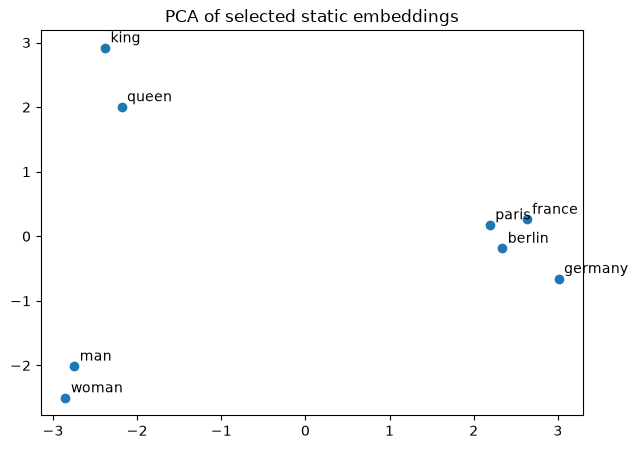

In [3]:
words = ['king', 'queen', 'man', 'woman', 'paris', 'france', 'berlin', 'germany']
coordinates = PCA(n_components=2, random_state=7).fit_transform([vectors[word] for word in words])
plt.figure(figsize=(7, 5))
plt.scatter(coordinates[:, 0], coordinates[:, 1])
for word, (x, y) in zip(words, coordinates):
    plt.annotate(word, (x, y), xytext=(4, 4), textcoords='offset points')
plt.title('PCA of selected static embeddings')
plt.show()


The two-dimensional PCA plot is illustrative. Reducing 50 dimensions to two does not preserve every relationship in the full embedding space.


## Construct a vector for an unseen spelling with FastText

A word-level lookup table cannot return a vector for a spelling absent from its vocabulary. FastText also learns vectors for character n-grams, so it can combine those fragments to represent some unseen spellings. This tiny fixed-seed corpus demonstrates the mechanism rather than embedding quality.


In [4]:
# A tiny deterministic mechanism demonstration, not a quality benchmark.
toy_sentences = [
    ['token', 'tokens', 'tokenizer'],
    ['embedding', 'embeddings', 'embedded'],
    ['tokenizer', 'splits', 'text'],
]
fasttext = FastText(
    sentences=toy_sentences, vector_size=16, window=2, min_count=1,
    sg=1, epochs=100, min_n=3, max_n=5, workers=1, seed=7,
)
unseen_spelling = 'tokenizers'
unseen_vector = fasttext.wv.get_vector(unseen_spelling)
print(f'FastText vector for unseen {unseen_spelling!r}: shape={unseen_vector.shape}')
print('The vector is composed from learned character n-gram vectors.')


FastText vector for unseen 'tokenizers': shape=(16,)
The vector is composed from learned character n-gram vectors.


GloVe returns one vector per vocabulary item. This is why it cannot represent a new spelling and why `bank` has the same vector in river-bank and bank-account contexts. FastText uses character n-gram vectors and can construct vectors for some unseen spellings. Later contextual models compute a representation for each occurrence from its surrounding tokens.
